<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Multivariate_Imputation_MICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mice

MICE stands for Multivariate Imputation by Chained Equations

Types of missing data:
MCAR : Missing Completely At Random -> data was not collected for certain rows
MAR : Missing At Random -> optionally chizen nahi bhari, can be filled using relation with other rows
MNA : Missing Not At Random -> Data was removed deliberately

MICE is use for MAR -> better result, and only on input columns

Advantage:
- Accurate
- Slow
- Training set to server, memory load

1. Actual Dataset
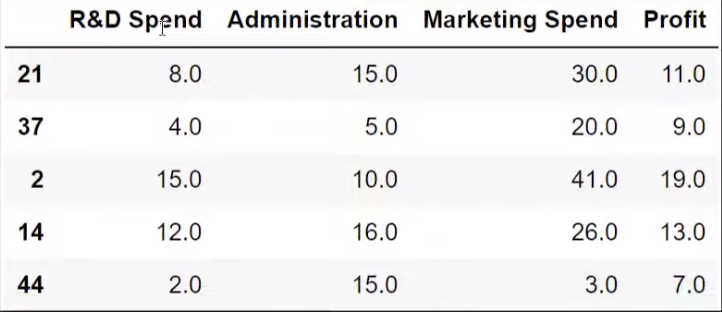

2. Removing target Columns

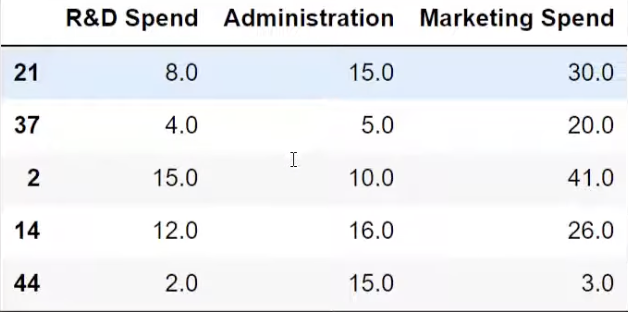

3. Introduced some fake nan values
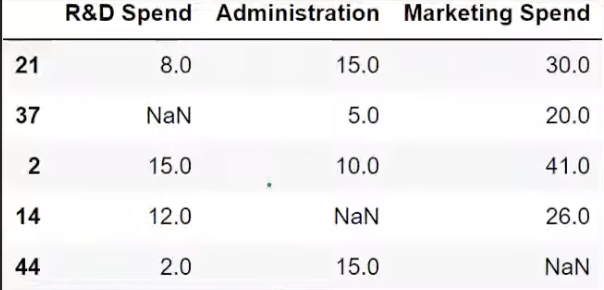

## STEPS

Step 1: Fill NaN values with mean of respective cols

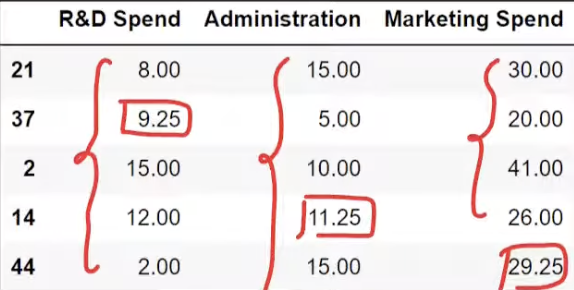

STAGE 0 complete

Step 2: Replace these new value left to right by NaN again

- We use this as target col and others as training data and use any model to predict

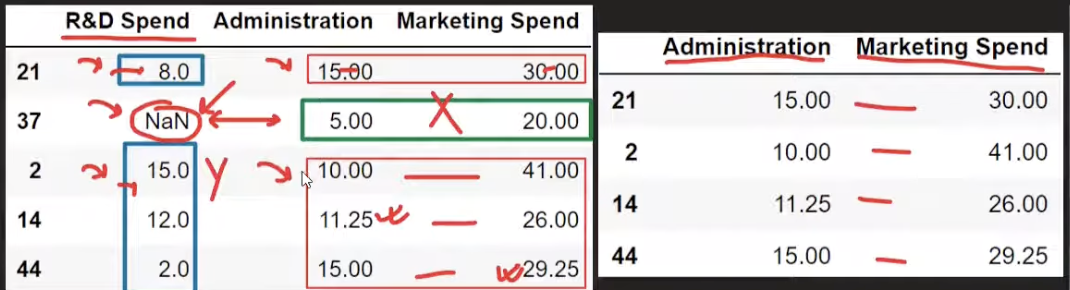

5 and 20 will be new input and prediction is 23.14

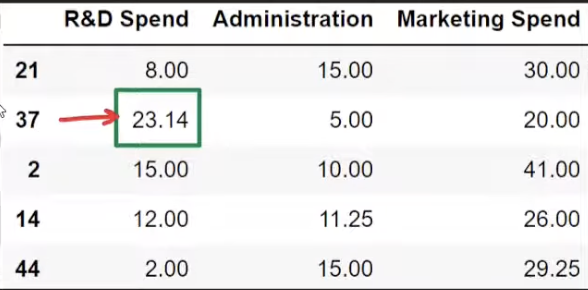

Step 3 - Already done above i.e predict the missing data

Step 4: do for other col and predict

Step 5: Predict

STAGE 1 complete

But this is not it we repeat the process again and again

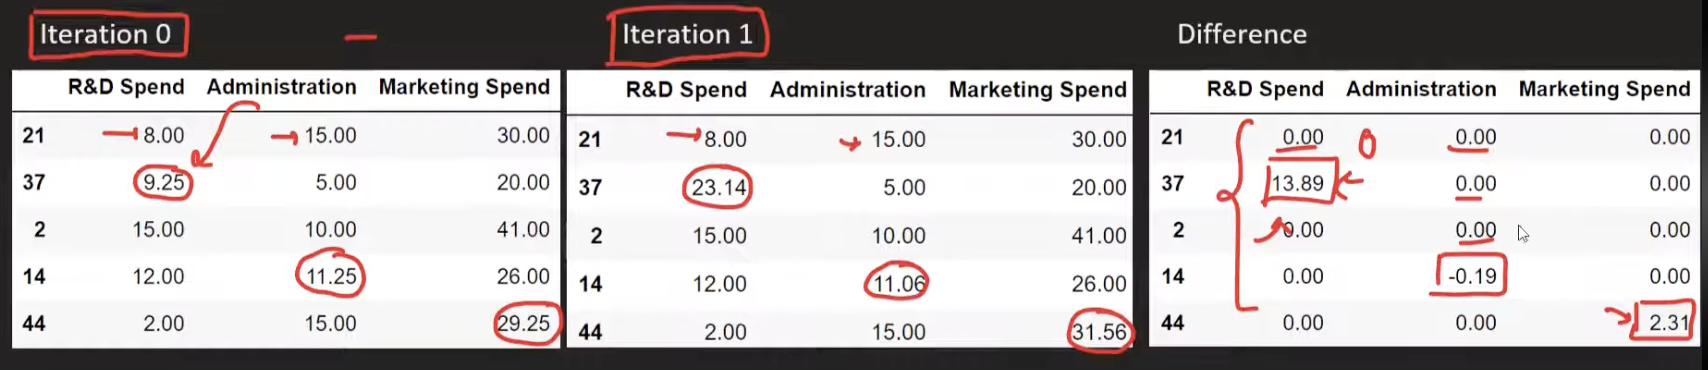

**Iteration 1 will become base as Iteration 0 mean value and new predictions will be done and if difference is near 0 thats a good prediction**

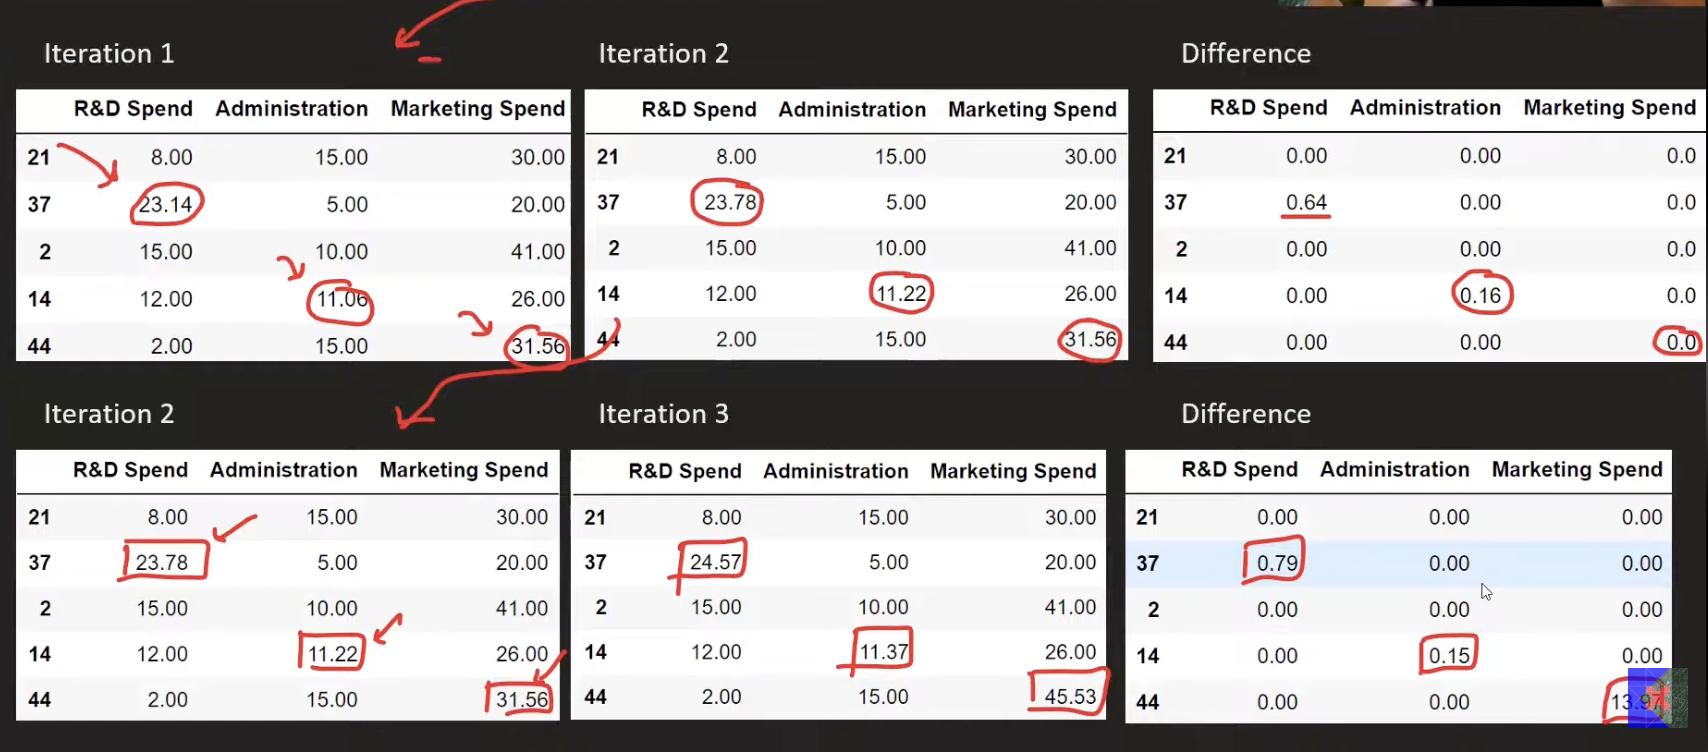

# Using scikit learn


```
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
 df = np.round(pd.read_csv('50_Startups.csv')[['R&D Spend','Administration','Marketing Spend','Profit']]/10000)
np.random.seed(9)
df = df.sample(5)
df
x_train = df.drop('Profit',axis=1)
y_train = df['Profit']
x_train,x_test,y_train,y_test = train_test_split(x_train,y_train,test_size=0.3,random_state=0)
# Step 1: Create IterativeImputer
imputer = IterativeImputer(estimator=LinearRegression(), random_state=0)

# Step 2: Fit the imputer on x_train only (never on x_test)
imputer.fit(x_train)

# Step 3: Transform both train and test sets
x_train_imputed = imputer.transform(x_train)
x_test_imputed = imputer.transform(x_test)
lr=LinearRegression()
lr.fit(x_train_imputed,y_train)
y_pred=lr.predict(x_test_imputed)
r2_score(y_test,y_pred)
```

